# Structure Learning for MNIST with a Renormalising Generative Model

Strongly inspired by (but not a direct reproduction of) Friston et al. (2025) *From pixels to planning: scale-free active inference.* Front. Netw. Physiol. 5:1521963

In [1]:
from utils import load_mnist

x_train, y_train, x_test, y_test = load_mnist()


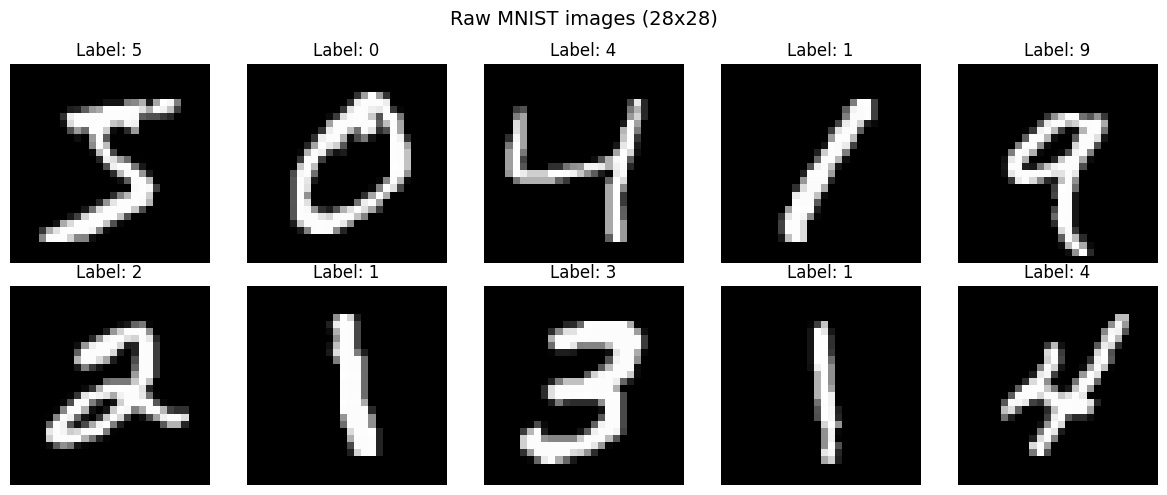

In [2]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

fig.suptitle('Raw MNIST images (28x28)', fontsize=14)
plt.tight_layout()
plt.show()

## Select Structure Learning Exemplars
From the paper (p.10):

> Based on the prior that there can be a dozen ways of writing any given number, the first 13 (Baker's dozen) images of each digit class were used for fast structure learning.

These 130 images (13 per class x 10 classes) are used to build the initial RGM hierarchy via fast structure learning. The remaining images are used for active learning.

In [3]:
import jax
from jax import numpy as jnp

In [4]:
from utils import extract_exemplars

M_PER_CLASS = 13  # Baker's dozen
NUM_CLASSES = 10

x_exemplars_raw, y_exemplars, exemplar_idx = extract_exemplars(x_train, y_train, M_PER_CLASS, NUM_CLASSES)
print(f"Exemplar images: {x_exemplars_raw.shape}")
print(f"Per class: {[(y_exemplars == d).sum().item() for d in range(10)]}")

Exemplar images: (130, 28, 28)
Per class: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13]


In [5]:
from preprocess import preprocess

x_exemplars = preprocess(x_exemplars_raw)
print(f"Preprocessed exemplars: {x_exemplars.shape}")

Preprocessed exemplars: (130, 32, 32)


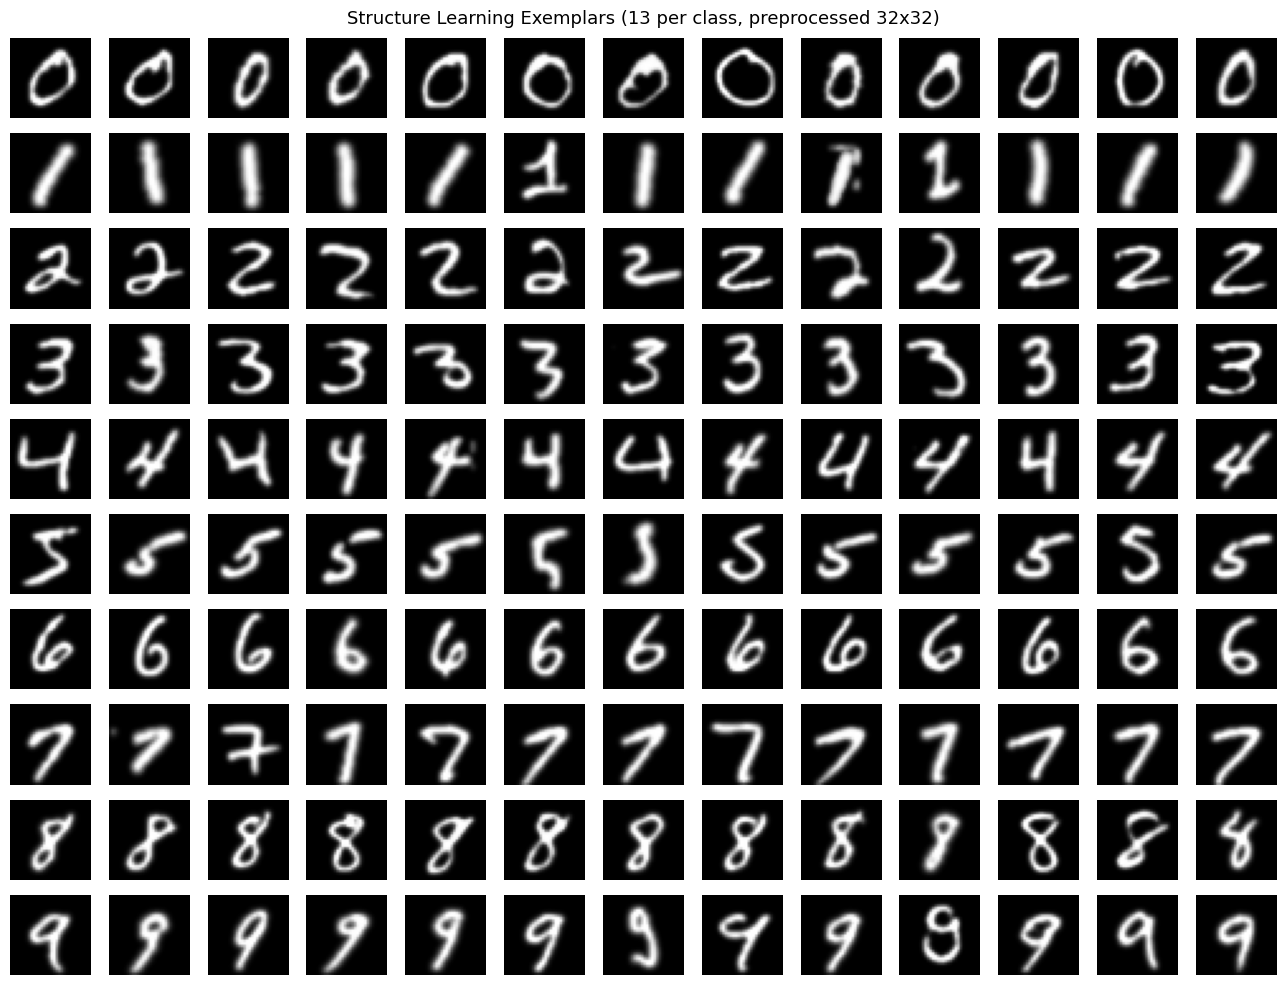

In [6]:
fig, axes = plt.subplots(NUM_CLASSES, M_PER_CLASS, figsize=(M_PER_CLASS, NUM_CLASSES))
for digit in range(NUM_CLASSES):
    mask = y_exemplars == digit
    digit_imgs = x_exemplars[mask]
    for j in range(M_PER_CLASS):
        axes[digit, j].imshow(digit_imgs[j], cmap='gray')
        axes[digit, j].axis('off')
    axes[digit, 0].set_ylabel(str(digit), rotation=0, fontsize=12, labelpad=15)
fig.suptitle(f'Structure Learning Exemplars ({M_PER_CLASS} per class, preprocessed 32x32)', fontsize=13)
plt.tight_layout()
plt.show()

## Discretisation using Singular Value Decomposition (SVD)

From the paper (p.8-10): Images are tessellated into 4x4 patches. Each patch location gets its own SVD basis learned from the structure exemplars. Continuous singular variates are quantised into 7 discrete levels, producing a discrete observation tensor per image.

The main text in the paper says:

> "Each group is then subject to singular value decomposition, given a training set of images, to identify an orthogonal (spatial) basis set of singular vectors. This grouping is followed by a reduction operator that retains singular variates with large singular values (here, the first 32 principal vectors based on groups of 4 × 4 pixels)."

> "The set of singular variates for each group specifies the pattern for any given image at the corresponding location. The continuous variates can then be quantized to a discrete number of levels (here, seven)."

However the figure 4 caption says:

> "...in this example, the singular variates could take seven discrete values centered on zero for a maximum of 16 singular vectors."

And footnote 7 says:

> "In practice, we use overlapping groups, where the singular value decomposition is applied following weighting by a radial (Gaussian) basis function whose standard deviation is the distance between group centers."

SPM alignment notes:

- SVD modes are selected adaptively via spm_svd(Y, 1/su) where su=8, retaining only modes with normalized singular values above 1/su. This is capped at mm=16 max modes.
- Bin assignment uses nearest-centre (not edge-based) matching SPM's [~, U] = min(abs(u(t,m) - a)).
- The number of retained modes varies per patch location.

Here we will use overlapping groups, as that seems sensible given the discussion points about receptive fields later in the paper. 

In [7]:
from discretise import (
    DiscretiseConfig,
    compute_svd_basis_overlapping, 
    encode_images_overlapping, 
    decode_observations_overlapping,
)

config = DiscretiseConfig()

basis = compute_svd_basis_overlapping(x_exemplars, config)
obs = encode_images_overlapping(x_exemplars, basis)
recon = decode_observations_overlapping(obs, basis)

print(f"  V shape:       {basis.V.shape}")
print(f"  Modes/patch:   min={int(basis.n_modes.min())}, max={int(basis.n_modes.max())}, mean={float(basis.n_modes.mean()):.1f}")
print(f"  MSE:           {float(((x_exemplars - recon[:, 0]) ** 2).mean()):.2f}")

  V shape:       (8, 8, 1024, 16)
  Modes/patch:   min=5, max=16, mean=12.2
  MSE:           79.01


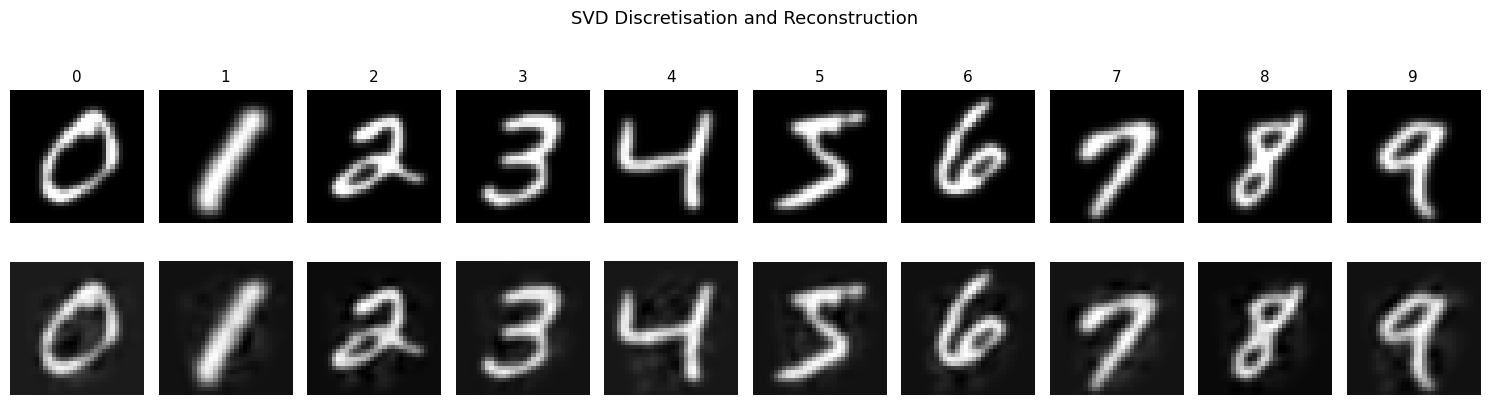

In [8]:
# Show impact of discretisation on information loss

show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4.5))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(x_exemplars[idx], cmap='gray')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(recon[idx, 0], cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Overlapping', fontsize=11)
fig.suptitle('SVD Discretisation and Reconstruction', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
from hierarchy import RGMHierarchy

rgm = RGMHierarchy.from_exemplars(x_exemplars, y_exemplars, config)

/home/arun-niranjan/repos/pymdp/examples/renormalising_generative_models/hierarchy.py:197: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


In [10]:
import numpy as np

# Hierarchy summary
print(f"Number of levels: {len(rgm.levels)} ({len(rgm.hierarchical_levels)} hierarchical + 1 classification)")
for lv, level in enumerate(rgm.hierarchical_levels):
    grid = level.stats.num_states
    n_grid = grid.shape[0]
    print(f"  L{lv+1}: {n_grid}x{n_grid} grid, "
          f"states/location: {int(grid.min())}-{int(grid.max())} "
          f"(mean {float(grid.mean()):.1f})")

# Classification level: P(top_state | digit) from the cls_agent's A matrix
n_top = int(rgm.hierarchical_levels[-1].stats.num_states[0, 0])
cls_A = np.asarray(rgm.cls_agent.A[0][0])  # (n_top_states, n_classes)
print(f"\nTop-level states: {n_top}")
print(f"Classification level: {n_top} states -> {rgm.n_classes} digit classes")
for d in range(rgm.n_classes):
    col = cls_A[:, d]
    n_active = (col > 0).sum()
    top3 = np.argsort(col)[::-1][:3]
    top3_str = ", ".join(f"s{s}({col[s]:.2f})" for s in top3)
    print(f"  Digit {d}: {n_active} contributing states, top: {top3_str}")

Number of levels: 5 (4 hierarchical + 1 classification)
  L1: 8x8 grid, states/location: 9-130 (mean 74.4)
  L2: 4x4 grid, states/location: 30-130 (mean 102.2)
  L3: 2x2 grid, states/location: 130-130 (mean 130.0)
  L4: 1x1 grid, states/location: 130-130 (mean 130.0)

Top-level states: 130
Classification level: 130 states -> 10 digit classes
  Digit 0: 13 contributing states, top: s96(0.08), s119(0.08), s46(0.08)
  Digit 1: 13 contributing states, top: s105(0.08), s114(0.08), s12(0.08)
  Digit 2: 13 contributing states, top: s123(0.08), s124(0.08), s26(0.08)
  Digit 3: 13 contributing states, top: s129(0.08), s128(0.08), s122(0.08)
  Digit 4: 13 contributing states, top: s125(0.08), s127(0.08), s74(0.08)
  Digit 5: 13 contributing states, top: s78(0.08), s121(0.08), s79(0.08)
  Digit 6: 13 contributing states, top: s102(0.08), s107(0.08), s67(0.08)
  Digit 7: 13 contributing states, top: s116(0.08), s126(0.08), s47(0.08)
  Digit 8: 13 contributing states, top: s97(0.08), s100(0.08), s2

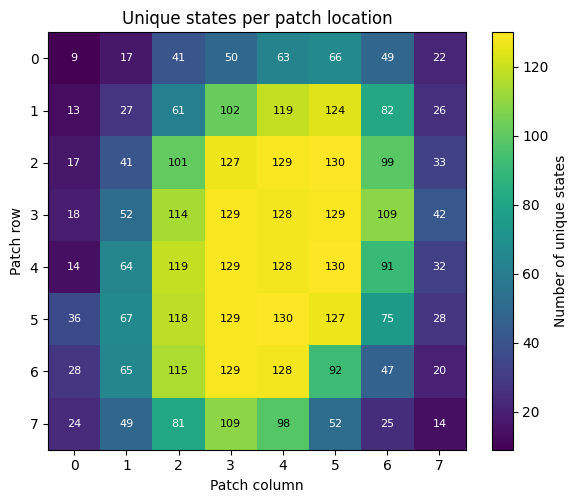

In [11]:
# Patch state count heatmap (Level 1)
l1_stats = rgm.levels[0].stats

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(l1_stats.num_states, cmap='viridis')
ax.set_title('Unique states per patch location')
ax.set_xlabel('Patch column')
ax.set_ylabel('Patch row')
for i in range(l1_stats.num_states.shape[0]):
    for j in range(l1_stats.num_states.shape[1]):
        ax.text(j, i, int(l1_stats.num_states[i, j]), ha='center', va='center',
                color='white' if l1_stats.num_states[i, j] < l1_stats.num_states.max() * 0.7 else 'black',
                fontsize=8)
fig.colorbar(im, ax=ax, label='Number of unique states')
plt.tight_layout()
plt.show()

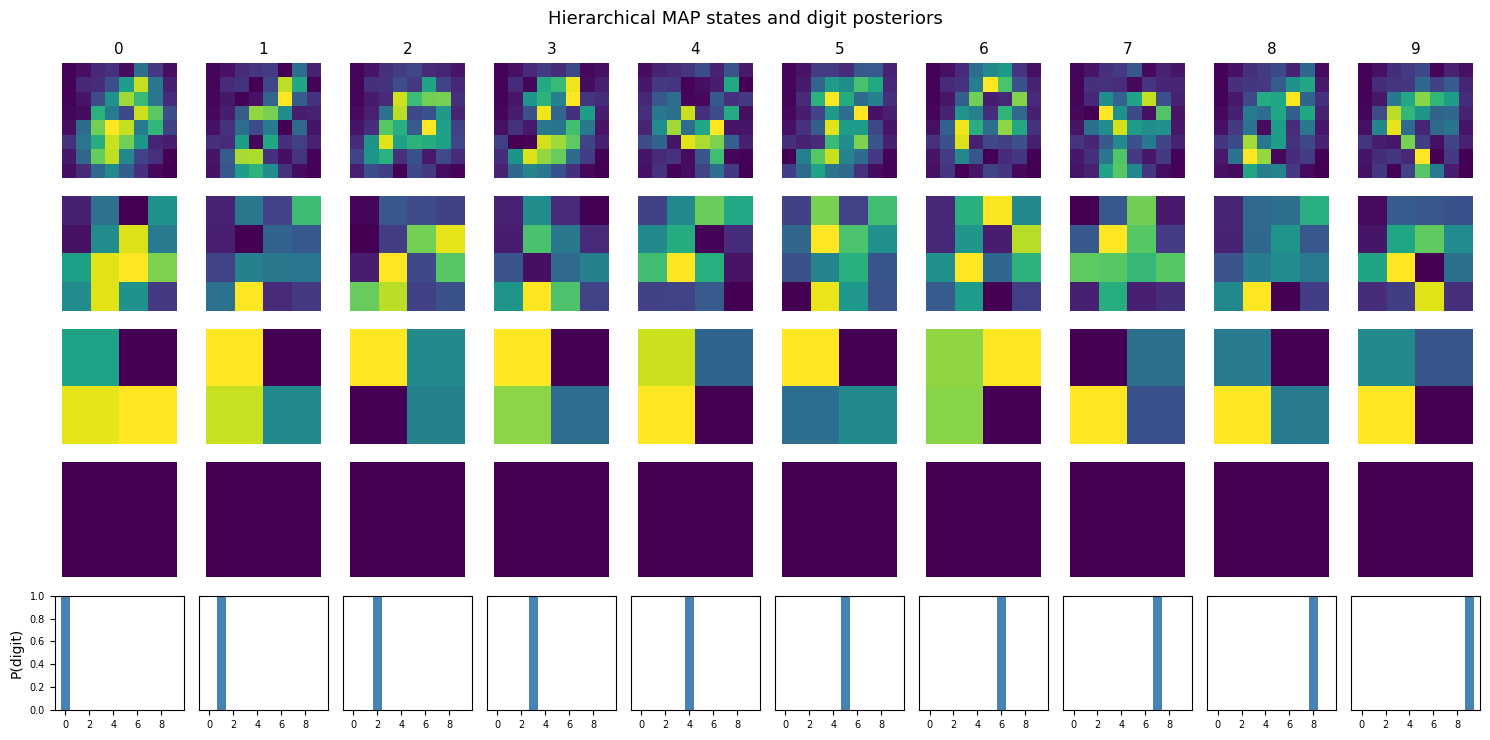

In [12]:
from hierarchy import infer_patch_states, infer_hierarchical_states, _infer_beliefs
from discretise import encode_images_overlapping

# Encode exemplars and pick one image per digit
observations = encode_images_overlapping(x_exemplars, rgm.basis)
show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

hier_levels = rgm.hierarchical_levels
n_hier = len(hier_levels)
n_rows = n_hier + 1  # hierarchical levels + classification row

fig, axes = plt.subplots(n_rows, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, n_rows * 1.5))
for col, idx in enumerate(show_idx):
    # L1: patch inference
    maps = infer_patch_states(hier_levels[0].agent, hier_levels[0].valid_mask, observations[idx])
    axes[0, col].imshow(maps, cmap='viridis')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    # L2+: hierarchical inference
    for lv, level in enumerate(hier_levels[1:], 1):
        maps = infer_hierarchical_states(level.agent, level.valid_mask, maps)
        axes[lv, col].imshow(maps, cmap='viridis')
        axes[lv, col].axis('off')
    # Classification level: digit posterior as a bar chart
    # cls_agent uses categorical_obs=True — convert MAP state to one-hot
    s_top = int(maps[0, 0])
    obs_list = [jax.nn.one_hot(jnp.array([s_top]), rgm.cls_agent.num_obs[0])]
    beliefs = _infer_beliefs(rgm.cls_agent, rgm.cls_valid_mask, obs_list)[0]
    axes[n_hier, col].bar(range(rgm.n_classes), beliefs, color='steelblue')
    axes[n_hier, col].set_ylim(0, 1)
    axes[n_hier, col].set_xticks(range(0, 10, 2))
    axes[n_hier, col].tick_params(labelsize=7)
    if col > 0:
        axes[n_hier, col].set_yticks([])

for lv in range(n_hier):
    grid_size = hier_levels[lv].stats.num_states.shape[0]
    axes[lv, 0].set_ylabel(f'L{lv+1} ({grid_size}x{grid_size})', fontsize=10)
axes[n_hier, 0].set_ylabel('P(digit)', fontsize=10)

fig.suptitle('Hierarchical MAP states and digit posteriors', fontsize=13)
plt.tight_layout()
plt.show()

## Classification and Generation
The RGMHierarchy object supports two key operations:

- classify: bottom-up inference on unseen images → digit prediction
- generate: top-down state lookup from digit prior → reconstructed pixel image

In [13]:
# Sanity check: classify the 130 structure exemplars (should be 100%)
pred_exemplars, l4_exemplars, digit_beliefs = rgm.classify(x_exemplars)
exemplar_acc = (pred_exemplars == np.array(y_exemplars)).mean()
print(f"Structure exemplar accuracy: {exemplar_acc:.1%} ({(pred_exemplars == np.array(y_exemplars)).sum()}/{len(y_exemplars)})")
if exemplar_acc < 1.0:
    mismatches = np.where(pred_exemplars != np.array(y_exemplars))[0]
    for idx in mismatches[:10]:
        print(f"  Image {idx}: true={y_exemplars[idx]}, pred={pred_exemplars[idx]}, L4 state={l4_exemplars[idx]}")

Structure exemplar accuracy: 100.0% (130/130)


Test accuracy (100 images): 48.0%
  Digit 0: 37.5% (3/8)
  Digit 1: 92.9% (13/14)
  Digit 2: 37.5% (3/8)
  Digit 3: 45.5% (5/11)
  Digit 4: 50.0% (7/14)
  Digit 5: 0.0% (0/7)
  Digit 6: 90.0% (9/10)
  Digit 7: 33.3% (5/15)
  Digit 8: 0.0% (0/2)
  Digit 9: 27.3% (3/11)


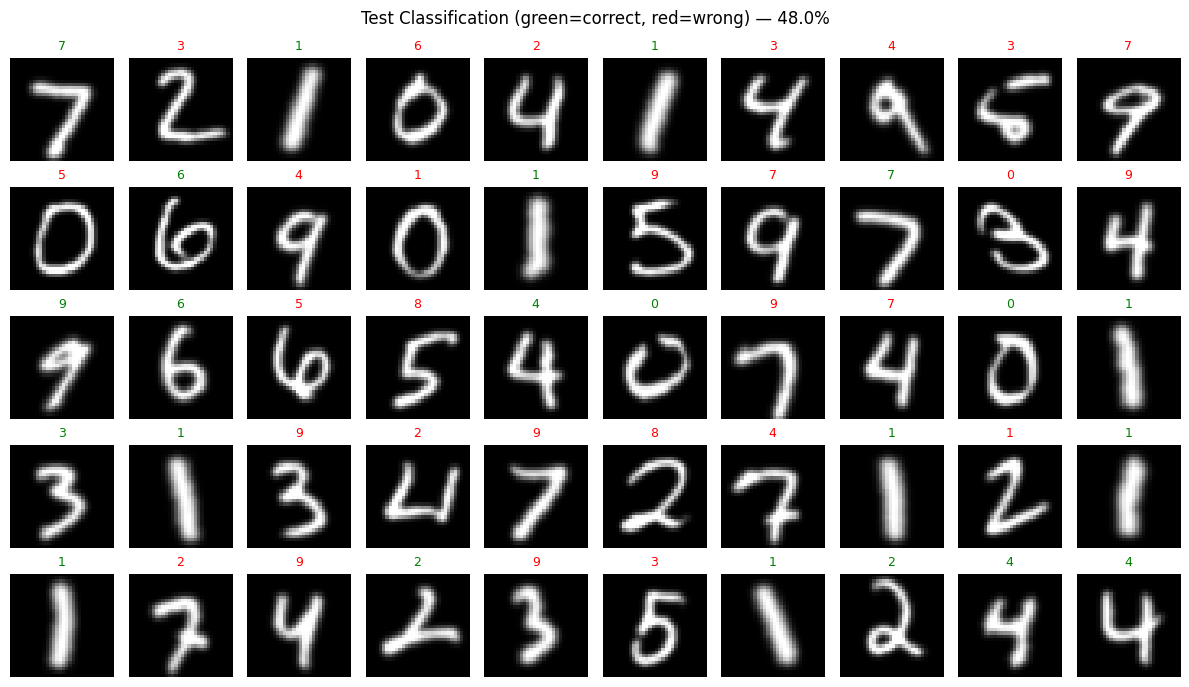

In [14]:
# Classify first 100 test images
N_TEST = 100
x_test_pre = preprocess(x_test[:N_TEST])
y_test_sub = np.array(y_test[:N_TEST])

pred_test, l4_test, digit_beliefs = rgm.classify(x_test_pre)
test_acc = (pred_test == y_test_sub).mean()
print(f"Test accuracy ({N_TEST} images): {test_acc:.1%}")

# Per-digit accuracy
for d in range(10):
    mask = y_test_sub == d
    if mask.sum() > 0:
        d_acc = (pred_test[mask] == d).mean()
        print(f"  Digit {d}: {d_acc:.1%} ({(pred_test[mask] == d).sum()}/{mask.sum()})")

# Show grid with color-coded predictions
n_show = min(50, N_TEST)
cols = 10
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.4))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(np.array(x_test_pre[i]), cmap='gray')
        correct = pred_test[i] == y_test_sub[i]
        color = 'green' if correct else 'red'
        ax.set_title(f"{pred_test[i]}", fontsize=9, color=color)
    ax.axis('off')
fig.suptitle(f'Test Classification (green=correct, red=wrong) — {test_acc:.1%}', fontsize=12)
plt.tight_layout()
plt.show()

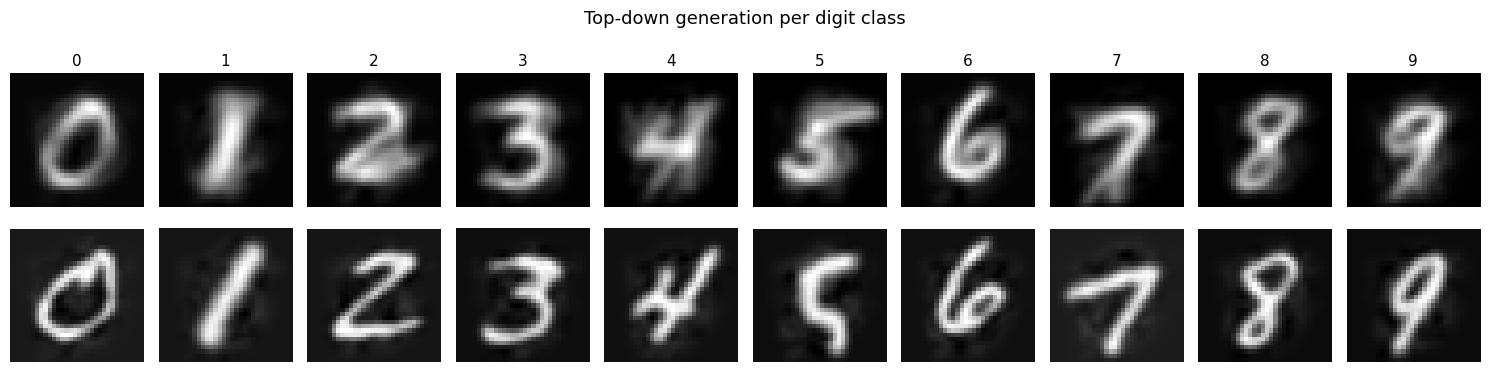

In [15]:
# Top-down generation: generate one image per digit class
import jax.random as jr

key = jr.PRNGKey(42)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4))

# Row 1: argmax (deterministic) generation
for d in range(NUM_CLASSES):
    img, _ = rgm.generate(digit=d)
    axes[0, d].imshow(np.array(img[0, 0]), cmap='gray')
    axes[0, d].set_title(str(d), fontsize=11)
    axes[0, d].axis('off')
axes[0, 0].set_ylabel('Argmax', fontsize=10)

# Row 2: sampled generation (split key each time)
for d in range(NUM_CLASSES):
    key, subkey = jr.split(key)
    img, _ = rgm.generate(digit=d, sample=True, key=subkey)
    axes[1, d].imshow(np.array(img[0, 0]), cmap='gray')
    axes[1, d].axis('off')
axes[1, 0].set_ylabel('Sampled', fontsize=10)

fig.suptitle('Top-down generation per digit class', fontsize=13)
plt.tight_layout()
plt.show()

## Active Learning (Parametric Training with Bidirectional Message Passing)

Following the SPM reference (`DEM_MNIST_RGM.m`), we refine all A matrices by processing training images sequentially. For each image:

1. **Bottom-up pass**: inference runs level by level with default D priors, producing soft beliefs at each level
2. **Classification**: inference with a supervised one-hot D prior (true label), giving the digit posterior
3. **Top-down pass**: the classification posterior is propagated back down — each level's beliefs are refined using top-down predictions from the level above as D priors
4. **Dirichlet updates**: all levels update their A matrices using the top-down corrected beliefs

This bidirectional scheme matches SPM's `FIX.A=0` setting, with initial Dirichlet concentrations `1/16` for hierarchical levels and `1/128` for the classification level.

In [16]:
# Preprocess full training set
x_train_pre = preprocess(x_train)
print(f"Training images: {x_train_pre.shape}")

Training images: (60000, 32, 32)


In [17]:
N_TRAIN = 10000

metrics = rgm.train(
    x_train_pre[:N_TRAIN],
    np.array(y_train[:N_TRAIN]),
    concentration_lower=1 / 16,
    concentration_cls=1 / 128,
    lr_pA=1.0,
    beta=512.0,
    eta=512.0,
    log_every=200,
)

  [200/10000] acc=0.880  MI: L1=670.850  L2=29.997  L3=6.646  L4=1.764  cls=1.834
  [400/10000] acc=0.755  MI: L1=672.914  L2=43.105  L3=8.287  L4=2.068  cls=1.846
  [600/10000] acc=0.713  MI: L1=674.023  L2=54.995  L3=10.327  L4=2.454  cls=1.874
  [800/10000] acc=0.711  MI: L1=674.828  L2=64.781  L3=12.294  L4=2.856  cls=1.893
  [1000/10000] acc=0.719  MI: L1=676.218  L2=72.942  L3=14.249  L4=3.318  cls=1.924
  [1200/10000] acc=0.720  MI: L1=676.872  L2=79.022  L3=16.045  L4=3.752  cls=1.927
  [1400/10000] acc=0.719  MI: L1=676.924  L2=82.469  L3=17.194  L4=4.063  cls=1.922
  [1600/10000] acc=0.728  MI: L1=677.481  L2=87.027  L3=18.802  L4=4.513  cls=1.939
  [1800/10000] acc=0.743  MI: L1=677.853  L2=91.628  L3=20.491  L4=4.985  cls=1.956
  [2000/10000] acc=0.750  MI: L1=677.994  L2=94.332  L3=21.524  L4=5.286  cls=1.938
  [2200/10000] acc=0.759  MI: L1=678.124  L2=96.469  L3=22.505  L4=5.559  cls=1.925
  [2400/10000] acc=0.769  MI: L1=678.410  L2=99.005  L3=23.609  L4=5.917  cls=1.92

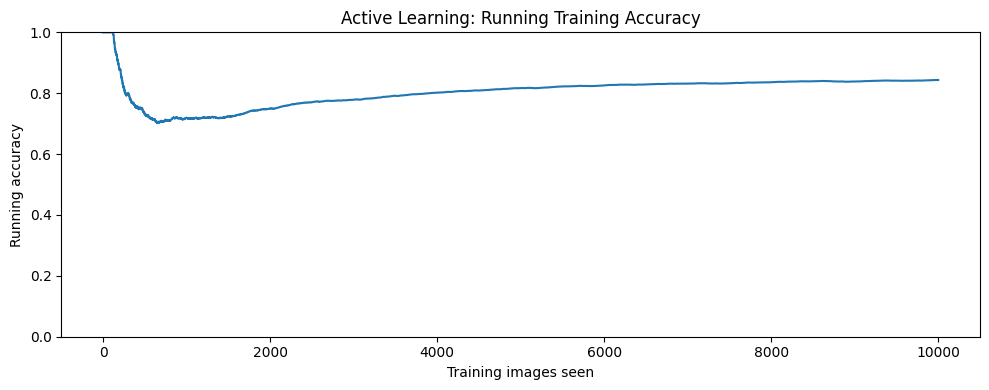

In [18]:
# Plot running training accuracy
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(metrics["running_accuracy"])
ax.set_xlabel("Training images seen")
ax.set_ylabel("Running accuracy")
ax.set_title("Active Learning: Running Training Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

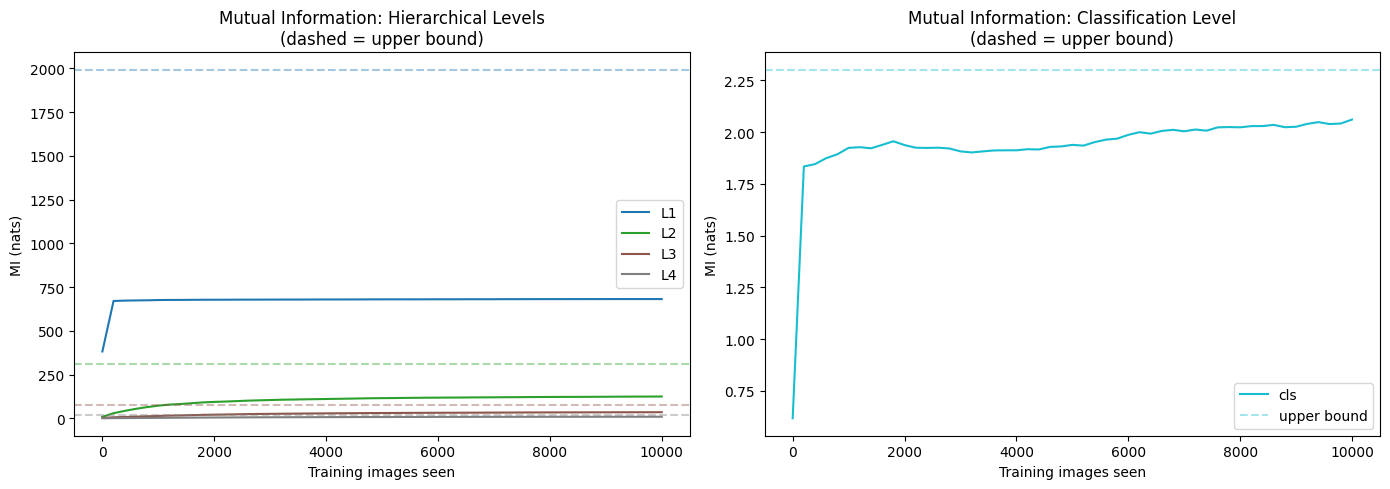

Level       MI (init)   MI (final)   Upper bound   % of max
----------------------------------------------------------
L1           382.4194     681.8044     1992.6120      34.2%
L2             9.2956     125.3115      311.5222      40.2%
L3             3.0074      35.6739       77.8806      45.8%
L4             0.8553       9.7492       19.4701      50.1%
cls            0.6174       2.0610        2.3026      89.5%


In [19]:
from hierarchy import compute_level_mi

# Plot mutual information per level over training
# Following spm_MDP_MI: I(o; s) = H(o) + H(s) - H(o,s) computed on normalised Dirichlet params
mi_arr = np.array(metrics["mi_history"])          # (n_checkpoints, n_levels)
checkpoints = metrics["mi_checkpoints"]
upper_bounds = metrics["mi_upper_bounds"]
n_levels = mi_arr.shape[1]
n_hier = len(rgm.hierarchical_levels)

level_names = [f"L{i+1}" for i in range(n_hier)] + ["cls"]
colors = plt.cm.tab10(np.linspace(0, 1, n_levels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all hierarchical levels
ax = axes[0]
for i in range(n_hier):
    ax.plot(checkpoints, mi_arr[:, i], color=colors[i], label=level_names[i])
    ax.axhline(upper_bounds[i], color=colors[i], linestyle='--', alpha=0.4)
ax.set_xlabel("Training images seen")
ax.set_ylabel("MI (nats)")
ax.set_title("Mutual Information: Hierarchical Levels\n(dashed = upper bound)")
ax.legend()

# Right: classification level
ax = axes[1]
ax.plot(checkpoints, mi_arr[:, -1], color=colors[-1], label="cls")
ax.axhline(upper_bounds[-1], color=colors[-1], linestyle='--', alpha=0.4, label="upper bound")
ax.set_xlabel("Training images seen")
ax.set_ylabel("MI (nats)")
ax.set_title("Mutual Information: Classification Level\n(dashed = upper bound)")
ax.legend()

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Level':<8} {'MI (init)':>12} {'MI (final)':>12} {'Upper bound':>13} {'% of max':>10}")
print("-" * 58)
for i, name in enumerate(level_names):
    print(f"{name:<8} {mi_arr[0, i]:>12.4f} {mi_arr[-1, i]:>12.4f} {upper_bounds[i]:>13.4f} "
          f"{100 * mi_arr[-1, i] / upper_bounds[i]:>9.1f}%")

In [20]:
# Re-evaluate on test set after active learning
pred_post, _, beliefs_post = rgm.classify(x_test_pre)
acc_post = (pred_post == y_test_sub).mean()
print(f"Test accuracy BEFORE training: {test_acc:.1%}")
print(f"Test accuracy AFTER  training: {acc_post:.1%}")

# Per-digit breakdown
print()
for d in range(10):
    mask = y_test_sub == d
    if mask.sum() > 0:
        before = (pred_test[mask] == d).mean()
        after = (pred_post[mask] == d).mean()
        print(f"  Digit {d}: {before:.1%} → {after:.1%}")

Test accuracy BEFORE training: 48.0%
Test accuracy AFTER  training: 91.0%

  Digit 0: 37.5% → 100.0%
  Digit 1: 92.9% → 100.0%
  Digit 2: 37.5% → 87.5%
  Digit 3: 45.5% → 90.9%
  Digit 4: 50.0% → 92.9%
  Digit 5: 0.0% → 85.7%
  Digit 6: 90.0% → 90.0%
  Digit 7: 33.3% → 86.7%
  Digit 8: 0.0% → 100.0%
  Digit 9: 27.3% → 81.8%


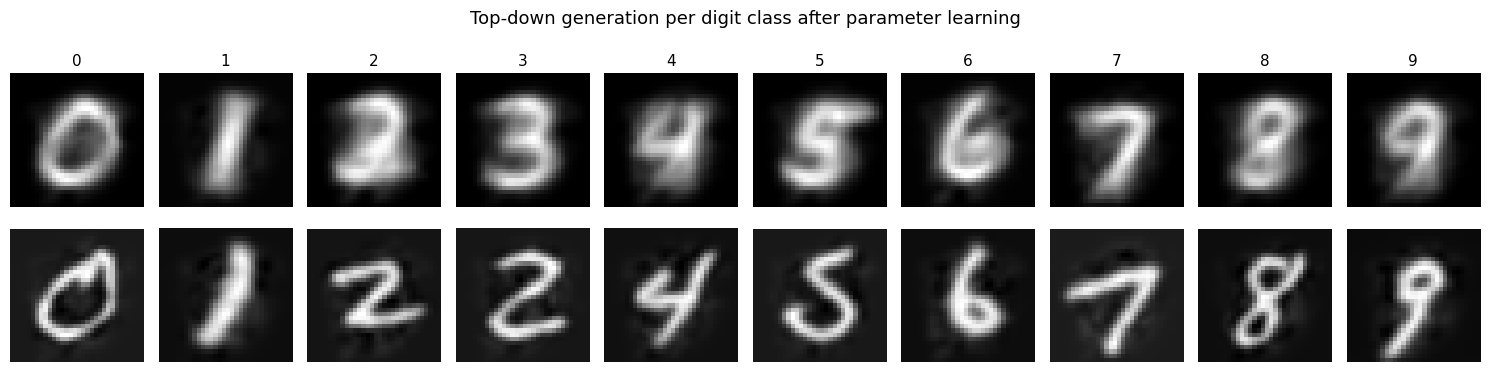

In [ ]:
# Top-down generation after parameter learning: generate one image per digit class
key = jr.PRNGKey(42)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4))

# Row 1: soft generation
for d in range(NUM_CLASSES):
    img, _ = rgm.generate(digit=d)
    axes[0, d].imshow(np.array(img[0, 0]), cmap='gray')
    axes[0, d].set_title(str(d), fontsize=11)
    axes[0, d].axis('off')
axes[0, 0].set_ylabel('Soft', fontsize=10)

# Row 2: sampled generation (split key each time)
for d in range(NUM_CLASSES):
    key, subkey = jr.split(key)
    img, _ = rgm.generate(digit=d, sample=True, key=subkey)
    axes[1, d].imshow(np.array(img[0, 0]), cmap='gray')
    axes[1, d].axis('off')
axes[1, 0].set_ylabel('Sampled', fontsize=10)

fig.suptitle('Top-down generation per digit class after parameter learning', fontsize=13)
plt.tight_layout()
plt.show()